## **Project Title: Predicting Student Academic Performance using PySpark**

###**Mounting Google Drive to access Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Initializing Spark and loading the data CSV**

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("StudentPerf").getOrCreate()

file_path = "/content/drive/MyDrive/MSDS-Q4-CSC555_FinalProject_Dataset/Student_performance_10k.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

print("Rows:", df.count(), "Cols:", len(df.columns))
df.printSchema()
df.show(5, truncate=False)


Rows: 10000 Cols: 12
root
 |-- roll_no: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- race_ethnicity: string (nullable = true)
 |-- parental_level_of_education: string (nullable = true)
 |-- lunch: integer (nullable = true)
 |-- test_preparation_course: integer (nullable = true)
 |-- math_score: string (nullable = true)
 |-- reading_score: integer (nullable = true)
 |-- writing_score: integer (nullable = true)
 |-- science_score: integer (nullable = true)
 |-- total_score: integer (nullable = true)
 |-- grade: string (nullable = true)

+-------+------+--------------+---------------------------+-----+-----------------------+----------+-------------+-------------+-------------+-----------+-----+
|roll_no|gender|race_ethnicity|parental_level_of_education|lunch|test_preparation_course|math_score|reading_score|writing_score|science_score|total_score|grade|
+-------+------+--------------+---------------------------+-----+-----------------------+----------+-------------+

### **Data Cleaning Step: Handling incorrect datatype and dropping unnecessary column.**

In [4]:
from pyspark.sql.functions import col

df = df.withColumn("math_score", col("math_score").cast("integer"))
df = df.drop("roll_no")  # drop ID column

df.printSchema()
df.show(5, truncate=False)


root
 |-- gender: string (nullable = true)
 |-- race_ethnicity: string (nullable = true)
 |-- parental_level_of_education: string (nullable = true)
 |-- lunch: integer (nullable = true)
 |-- test_preparation_course: integer (nullable = true)
 |-- math_score: integer (nullable = true)
 |-- reading_score: integer (nullable = true)
 |-- writing_score: integer (nullable = true)
 |-- science_score: integer (nullable = true)
 |-- total_score: integer (nullable = true)
 |-- grade: string (nullable = true)

+------+--------------+---------------------------+-----+-----------------------+----------+-------------+-------------+-------------+-----------+-----+
|gender|race_ethnicity|parental_level_of_education|lunch|test_preparation_course|math_score|reading_score|writing_score|science_score|total_score|grade|
+------+--------------+---------------------------+-----+-----------------------+----------+-------------+-------------+-------------+-----------+-----+
|male  |group D       |some college 

### **Checking for Null values in each columns and dropping rows with missing data.**

In [5]:
from pyspark.sql.functions import col, sum

# Count nulls in each column
null_counts = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])
null_counts.show()

# Drop rows with ANY nulls
df_clean = df.na.drop()

# Check new size after dropping nulls
print("Old row count:", df.count())
print("New row count:", df_clean.count())

df = df_clean  # Update working dataframe

+------+--------------+---------------------------+-----+-----------------------+----------+-------------+-------------+-------------+-----------+-----+
|gender|race_ethnicity|parental_level_of_education|lunch|test_preparation_course|math_score|reading_score|writing_score|science_score|total_score|grade|
+------+--------------+---------------------------+-----+-----------------------+----------+-------------+-------------+-------------+-----------+-----+
|    18|            23|                         22|   24|                     23|        25|           25|           24|           23|         19|    3|
+------+--------------+---------------------------+-----+-----------------------+----------+-------------+-------------+-------------+-----------+-----+

Old row count: 10000
New row count: 9787


### **Checking for duplicate data and dropping duplicate rows.**

In [6]:
# Check duplicate count
dup_count = df.count() - df.distinct().count()
print("Duplicate rows:", dup_count)

# Remove duplicates if any
df = df.dropDuplicates()
print("New row count after removing duplicates:", df.count())


Duplicate rows: 0
New row count after removing duplicates: 9787


### **Summary Stats & Target Distribution**

We now explore the dataset to understand its statistical properties. Summary statistics help us detect skew, outliers, or unusual values in numeric columns. We also check the distribution of the target variable (grade) to see how balanced our prediction classes are.

In [7]:
# Summary statistics for numeric columns
df.describe(["math_score", "reading_score", "writing_score", "science_score", "total_score"]).show()

# Distribution of the target variable 'grade'
df.groupBy("grade").count().orderBy("grade").show()


+-------+------------------+-----------------+------------------+-----------------+------------------+
|summary|        math_score|    reading_score|     writing_score|    science_score|       total_score|
+-------+------------------+-----------------+------------------+-----------------+------------------+
|  count|              9787|             9787|              9787|             9787|              9787|
|   mean|57.233370797997345|70.15867988147542| 71.45304996423828|66.07509962194749|264.92020026565854|
| stddev|21.710662105980344|19.02523029862728|18.237418432189656|19.30628548121429| 42.30410024148626|
|    min|                 0|               17|                10|                9|                89|
|    max|               100|              100|               100|              100|               383|
+-------+------------------+-----------------+------------------+-----------------+------------------+

+-----+-----+
|grade|count|
+-----+-----+
|    A|  895|
|    B| 5544|
| 

###  **Distribution of Final Grade Labels**
Visualizing the count of students in each grade category to understand label distribution and potential imbalance.


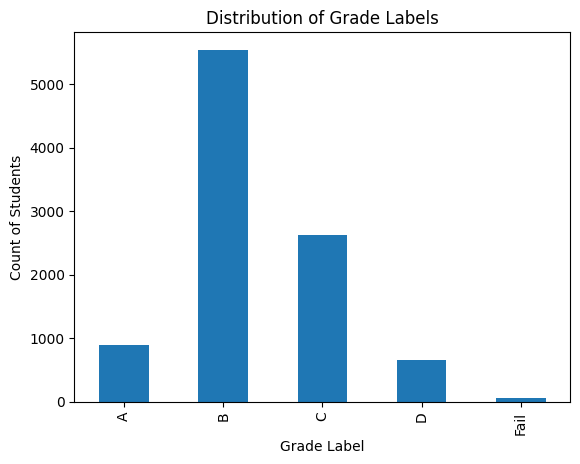

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert label column to Pandas
label_df = df.select("grade").toPandas()

# Plot
label_df['grade'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Grade Labels")
plt.xlabel("Grade Label")
plt.ylabel("Count of Students")
plt.show()


### **Boxplot of Math Scores by Grade Label**

Visualizing score distribution across different grade levels to understand correlation between raw performance and final grade.


<Figure size 800x500 with 0 Axes>

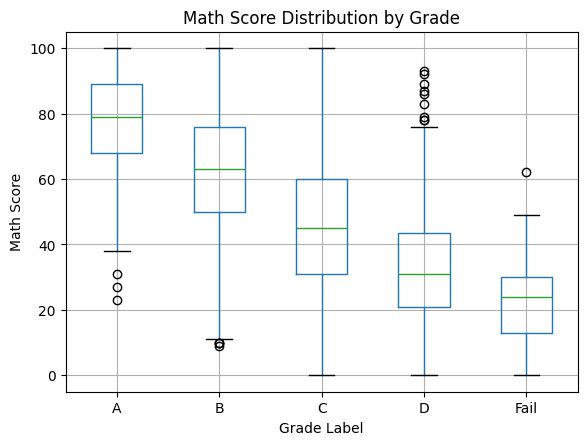

In [9]:
# Select relevant columns for Boxplot
score_df = df.select("math_score", "grade").toPandas()

plt.figure(figsize=(8,5))
score_df.boxplot(column="math_score", by="grade")
plt.title("Math Score Distribution by Grade")
plt.suptitle("")  # Remove automatic title
plt.xlabel("Grade Label")
plt.ylabel("Math Score")
plt.show()


**Inference from the plot**

The box plot demonstrates a strong positive correlation between the Math Score and the Grade Label, as the median score and score range consistently decrease when moving from 'A' to 'Fail', although outliers are present across all grade categories.

### **Impact of Test Preparation Course on Performance**
Comparing average total scores of students who completed test preparation vs those who did not.


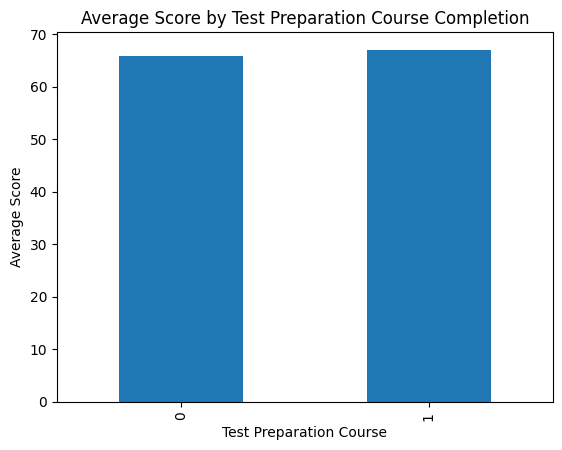

In [10]:
# Create average score column (Math, Reading, Writing)
from pyspark.sql.functions import expr

df_scores = df.withColumn("avg_score", expr("(math_score + reading_score + writing_score) / 3"))
prep_df = df_scores.select("test_preparation_course", "avg_score").toPandas()

# Group and plot
prep_avg = prep_df.groupby("test_preparation_course")["avg_score"].mean()

prep_avg.plot(kind="bar")
plt.title("Average Score by Test Preparation Course Completion")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.show()


**Inference from the plot:**

Completing the Test Preparation Course (labeled 1) has a negligible positive impact on the Average Score, given that the average score for completers is only marginally higher than the average for non-completers (labeled 0).

### **Label Indexing**

In [11]:
from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(inputCol="grade", outputCol="label", handleInvalid="skip")
df = label_indexer.fit(df).transform(df)

df.select("grade", "label").distinct().orderBy("label").show()


+-----+-----+
|grade|label|
+-----+-----+
|    B|  0.0|
|    C|  1.0|
|    A|  2.0|
|    D|  3.0|
| Fail|  4.0|
+-----+-----+



### **Computing the class count**

In [12]:
from pyspark.sql.functions import col

# Count how many examples are there for each label
df.groupBy("label").count().orderBy("label").show()


+-----+-----+
|label|count|
+-----+-----+
|  0.0| 5544|
|  1.0| 2628|
|  2.0|  895|
|  3.0|  659|
|  4.0|   61|
+-----+-----+



**From the output of class count as well as the distribution of grade labels, it is clear that there is a huge class imbalance and model will clearly disregard the minority, yet important, class "Fail" which has only 61 count. Therefore, it is highly crucial to compute classweight and include in model learning.**

In [13]:
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import udf

# Total samples and number of classes
total_count = df.count()
num_classes = df.select("label").distinct().count()

# Compute weights
class_counts = df.groupBy("label").count().collect()
class_weights = {row['label']: total_count/(num_classes*row['count']) for row in class_counts}

class_weights


{0.0: 0.3530663780663781,
 1.0: 0.7448249619482497,
 4.0: 32.088524590163935,
 3.0: 2.970257966616085,
 2.0: 2.187039106145251}

### **Adding a class weight column to the dataframe.**

In [14]:
# UDF to map label to its weight
weight_udf = udf(lambda label: float(class_weights[label]), DoubleType())

df = df.withColumn("classWeightCol", weight_udf(col("label")))

df.select("grade", "label", "classWeightCol").show(10)


+-----+-----+------------------+
|grade|label|    classWeightCol|
+-----+-----+------------------+
|    B|  0.0|0.3530663780663781|
|    D|  3.0| 2.970257966616085|
|    B|  0.0|0.3530663780663781|
|    C|  1.0|0.7448249619482497|
|    B|  0.0|0.3530663780663781|
|    B|  0.0|0.3530663780663781|
|    B|  0.0|0.3530663780663781|
|    B|  0.0|0.3530663780663781|
|    C|  1.0|0.7448249619482497|
|    B|  0.0|0.3530663780663781|
+-----+-----+------------------+
only showing top 10 rows



**This cell indexes all categorical columns using StringIndexer so that they can later be OneHotEncoded for ML.**

In [15]:
from pyspark.ml.feature import OneHotEncoder

# List all categorical columns except the label
categorical_cols = [field for (field, dtype) in df.dtypes if dtype == "string" and field != "grade"]

# StringIndexers for all categorical columns
indexers = [StringIndexer(inputCol=col, outputCol=col+"_indexed", handleInvalid="keep") for col in categorical_cols]

# Apply the indexers sequentially
from pyspark.ml import Pipeline
pipeline = Pipeline(stages=indexers)
df = pipeline.fit(df).transform(df)

# Show some results
df.select(categorical_cols + [col+"_indexed" for col in categorical_cols]).show(5)


+------+--------------+---------------------------+--------------+----------------------+-----------------------------------+
|gender|race_ethnicity|parental_level_of_education|gender_indexed|race_ethnicity_indexed|parental_level_of_education_indexed|
+------+--------------+---------------------------+--------------+----------------------+-----------------------------------+
|  male|       group E|                high school|           1.0|                   3.0|                                1.0|
|  male|       group C|               some college|           1.0|                   0.0|                                0.0|
|  male|       group B|         associate's degree|           1.0|                   2.0|                                2.0|
|  male|       group D|          bachelor's degree|           1.0|                   1.0|                                4.0|
|  male|       group E|               some college|           1.0|                   3.0|                             

**This cell OneHotEncodes all indexed categorical columns and assembles them together with numeric columns into a single `features` vector for ML training.**

In [16]:
from pyspark.ml.feature import VectorAssembler

# OneHotEncoder for all indexed categorical columns
encoder = OneHotEncoder(inputCols=[col+"_indexed" for col in categorical_cols],
                        outputCols=[col+"_ohe" for col in categorical_cols])

# List of numeric columns to include in features
numeric_cols = [field for (field, dtype) in df.dtypes if ((dtype == "double" or dtype == "int") and field not in ["label", "classWeightCol"])]

# Combine numeric + OHE categorical columns into a single features column
assembler = VectorAssembler(
    inputCols=numeric_cols + [col+"_ohe" for col in categorical_cols],
    outputCol="features"
)

# Create a pipeline for encoding + assembling
pipeline = Pipeline(stages=[encoder, assembler])
df = pipeline.fit(df).transform(df)

# Show the features column
df.select("features", "label", "classWeightCol").show(5, truncate=False)


+-----------------------------------------------------------------------------------------------+-----+------------------+
|features                                                                                       |label|classWeightCol    |
+-----------------------------------------------------------------------------------------------+-----+------------------+
|(32,[1,2,3,4,5,6,7,8,9,11,18,27],[1.0,48.0,76.0,80.0,100.0,304.0,1.0,3.0,1.0,1.0,1.0,1.0])     |0.0  |0.3530663780663781|
|(32,[0,2,3,4,5,6,7,11,15,26],[1.0,21.0,47.0,55.0,49.0,172.0,1.0,1.0,1.0,1.0])                  |3.0  |2.970257966616085 |
|(32,[0,1,2,3,4,5,6,7,8,9,11,17,28],[1.0,1.0,86.0,71.0,59.0,47.0,263.0,1.0,2.0,2.0,1.0,1.0,1.0])|0.0  |0.3530663780663781|
|(32,[1,2,3,4,5,6,7,8,9,11,16,30],[1.0,39.0,79.0,63.0,33.0,214.0,1.0,1.0,4.0,1.0,1.0,1.0])      |1.0  |0.7448249619482497|
|(32,[0,2,3,4,5,6,7,8,11,18,26],[1.0,33.0,66.0,64.0,92.0,255.0,1.0,3.0,1.0,1.0,1.0])            |0.0  |0.3530663780663781|
+---------------

**This cell splits the dataset into training and test sets (80% training, 20% test) while keeping all preprocessing already applied.**

In [17]:
# Split dataset into training and test sets
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# Show count of training and test sets
print(f"Training set count: {train_df.count()}")
print(f"Test set count: {test_df.count()}")


Training set count: 7906
Test set count: 1881


**This cell trains a RandomForestClassifier using the features and label columns, while applying the classWeightCol to handle class imbalance.**

In [18]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize RandomForestClassifier with class weights
rf = RandomForestClassifier(featuresCol="features", labelCol="label",
                            weightCol="classWeightCol", numTrees=100, maxDepth=5, seed=42)

# Train the model
rf_model = rf.fit(train_df)

# Make predictions on the test set
predictions = rf_model.transform(test_df)

# Show sample predictions
predictions.select("features", "label", "prediction", "probability").show(5, truncate=False)


+-----------------------------------------------------------------------------------+-----+----------+-----------------------------------------------------------------------------------------------------+
|features                                                                           |label|prediction|probability                                                                                          |
+-----------------------------------------------------------------------------------+-----+----------+-----------------------------------------------------------------------------------------------------+
|(32,[0,2,3,4,5,6,7,8,13,17,26],[1.0,93.0,55.0,80.0,42.0,270.0,3.0,2.0,1.0,1.0,1.0])|0.0  |0.0       |[0.460604017584435,0.29729927195387984,0.13042795146049851,0.09769384201671405,0.013974916984472674] |
|(32,[2,3,4,5,6,7,8,9,12,17,29],[79.0,46.0,95.0,63.0,283.0,2.0,2.0,3.0,1.0,1.0,1.0])|0.0  |0.0       |[0.4974635896377049,0.20947484198728478,0.21979944126638337,0.0660803493795657

**This cell evaluates the trained RandomForest model using accuracy and F1-score on the test set to measure its performance.**

In [19]:
# Initialize evaluator for accuracy
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")

# Initialize evaluator for F1-score
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")

# Calculate metrics
accuracy = evaluator_acc.evaluate(predictions)
f1_score = evaluator_f1.evaluate(predictions)

print(f"Test Set Accuracy = {accuracy:.4f}")
print(f"Test Set F1 Score = {f1_score:.4f}")


Test Set Accuracy = 0.9601
Test Set F1 Score = 0.9602


**This cell computes and displays the confusion matrix for the test set predictions to visualize how well the model predicts each grade class.**

In [20]:
from pyspark.mllib.evaluation import MulticlassMetrics

# Select prediction and label as RDD for MulticlassMetrics
prediction_and_labels = predictions.select("prediction", "label").rdd.map(tuple)

# Initialize metrics object
metrics = MulticlassMetrics(prediction_and_labels)

# Confusion matrix
conf_matrix = metrics.confusionMatrix().toArray()
print("Confusion Matrix:\n")
print(conf_matrix)


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Confusion Matrix:

[[1.001e+03 2.900e+01 1.000e+00 0.000e+00 0.000e+00]
 [3.100e+01 4.960e+02 0.000e+00 0.000e+00 0.000e+00]
 [1.200e+01 0.000e+00 1.680e+02 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 1.330e+02 2.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 8.000e+00]]


**This cell extracts and displays the feature importances from the trained RandomForest model to identify which features contributed most to predicting the grades.**

Number of features in RF model: 32
       feature  importance
6    feature_6    0.503473
5    feature_5    0.121635
2    feature_2    0.118220
4    feature_4    0.091742
3    feature_3    0.089652
11  feature_11    0.020767
10  feature_10    0.016325
7    feature_7    0.014279
9    feature_9    0.005692
1    feature_1    0.004200


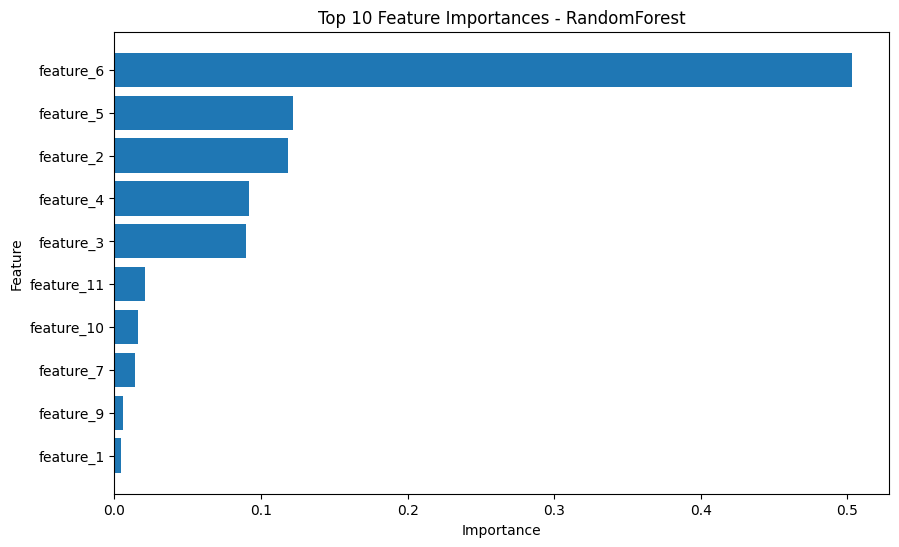

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from RF model
importances = rf_model.featureImportances.toArray()

# Total number of features in the features vector
num_features = len(importances)
print(f"Number of features in RF model: {num_features}")

# Create feature names placeholder (numeric + OHE)
# Note: OHE categorical columns expand to multiple dimensions — Spark doesn't give names per dummy variable
feature_names = numeric_cols + [col+"_ohe" for col in categorical_cols]

# If lengths mismatch, just label OHE features generically
if len(feature_names) != num_features:
    feature_names = [f"feature_{i}" for i in range(num_features)]

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Show top 10 important features
print(feat_imp_df.head(10))

# Plot top 10
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'].head(10), feat_imp_df['importance'].head(10))
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - RandomForest")
plt.gca().invert_yaxis()
plt.show()


**Method to extract full feature names with OHE expansion**

In [22]:
# Get the input feature names used in the VectorAssembler
feature_names = assembler.getInputCols()

# Get the importance scores from Random Forest
importances = rf_model.featureImportances.toArray()

# Combine into a pandas DataFrame
df_importance = pd.DataFrame(list(zip(feature_names, importances)),
                             columns=["feature", "importance"])

# Sort by importance descending
df_importance = df_importance.sort_values(by="importance", ascending=False)

df_importance.head(10)


,feature,importance
6,total_score,0.503473
5,science_score,0.121635
2,math_score,0.118220
4,writing_score,0.091742
3,reading_score,0.089652
11,race_ethnicity_ohe,0.020767
10,gender_ohe,0.016325
7,gender_indexed,0.014279
9,parental_level_of_education_indexed,0.005692
1,test_preparation_course,0.004200


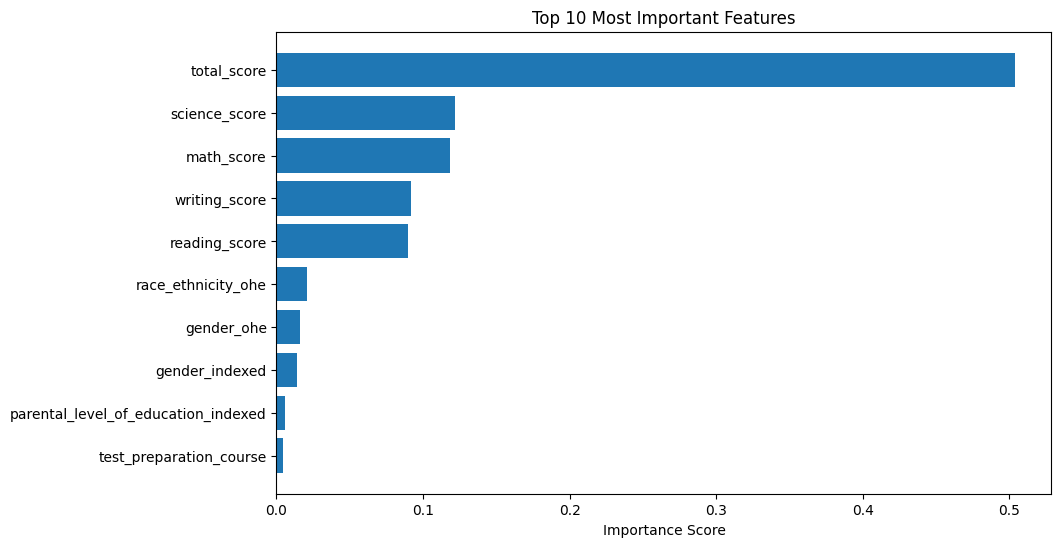

In [23]:
import matplotlib.pyplot as plt

# Take top 10 most important features
top_features = df_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()  # Highest importance at top
plt.xlabel("Importance Score")
plt.title("Top 10 Most Important Features")
plt.show()


**The following cell includes:**

**A hyperparameter grid for RandomForest and sets up CrossValidator to perform k-fold model tuning.**


In [31]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Define RandomForest model (required before grid)
rf = RandomForestClassifier(labelCol="label", featuresCol="features")

# Minimal hyperparameter combinations for quick execution
paramGrid = (ParamGridBuilder()
             .addGrid(rf.maxDepth, [3, 5, 10])
             .addGrid(rf.numTrees, [10, 20, 30])
             .addGrid(rf.maxBins, [16, 32])
             .build())

print(f"Total combinations to test: {len(paramGrid)}")

# Prepare evaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# Use 2 folds instead of 3 for faster testing
crossval = CrossValidator(estimator=rf,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=2)

print("Starting CrossValidator training")

# Fit with periodic progress updates
try:
    cv_model = crossval.fit(train_df)
    print("CrossValidator completed successfully!")

    best_rf_model = cv_model.bestModel
    print("\n Best Model Parameters:")
    print("Best numTrees:", best_rf_model.getNumTrees)
    print("Best maxDepth:", best_rf_model.getOrDefault("maxDepth"))
    print("Best maxBins:", best_rf_model.getOrDefault("maxBins"))

except Exception as e:
    print("Error during CrossValidator:", e)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

predictions = best_rf_model.transform(test_df)

accuracy = MulticlassClassificationEvaluator(metricName="accuracy").evaluate(predictions)
f1 = MulticlassClassificationEvaluator(metricName="f1").evaluate(predictions)

print(f"\n Performance of Best Model → Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}")


Total combinations to test: 18
Starting CrossValidator training
CrossValidator completed successfully!

 Best Model Parameters:
Best numTrees: 20
Best maxDepth: 10
Best maxBins: 32

 Performance of Best Model → Accuracy: 0.9724, F1 Score: 0.9701


### **Inference**

The best Random Forest model achieved high accuracy (97.24%) and strong F1 score (97.01%), indicating excellent predictive performance with balanced precision and recall.
The chosen hyperparameters **(20 trees, depth 10, and 32 bins)** effectively captured the patterns in the data without significant overfitting.

### **Model Training and Performance Comparison**

In this step, we compare the performance of multiple multiclass classification algorithms using PySpark's `ml` library. We begin by importing commonly used classifiers such as **Random Forest**, **Logistic Regression**, and **Decision Tree**. To ensure fair comparison, the same training and test datasets (`train_df` and `test_df`) are used across all models.

We evaluate each model based on two key metrics:

- **Accuracy** – Measures how often the model correctly classifies the labels.
- **F1 Score** – A harmonic mean of precision and recall, useful especially when class imbalance exists.

For each model, we train the classifier, make predictions, and compute the evaluation metrics. The results are collected in a list, converted into a Spark DataFrame for cleaner display, and then printed. Additionally, the **Logistic Regression model** instance is separately stored in `best_lr_model` for potential future tasks such as hyperparameter tuning, saving, or making further predictions.

This structured comparison helps in understanding which algorithm performs better for our current dataset and problem type.


In [26]:
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression, DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize evaluators
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

# Define multiclass models
models = {
    "RandomForest": RandomForestClassifier(labelCol="label", featuresCol="features"),
    "LogisticRegression": LogisticRegression(labelCol="label", featuresCol="features", maxIter=50),
    "DecisionTree": DecisionTreeClassifier(labelCol="label", featuresCol="features")
}

results = []

# Train, predict, and evaluate each model
best_lr_model = None  # to store logistic regression model

for name, model in models.items():
    fitted_model = model.fit(train_df)
    predictions = fitted_model.transform(test_df)

    accuracy = evaluator_accuracy.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)

    results.append((name, round(accuracy, 4), round(f1, 4)))

    # Save Logistic Regression model
    if name == "LogisticRegression":
        best_lr_model = fitted_model  # storing it for later use

# Display comparison results
results_df = spark.createDataFrame(results, ["Model", "Accuracy", "F1 Score"])
results_df.show()

print("\nLogistic Regression model is saved in variable: best_lr_model")


+------------------+--------+--------+
|             Model|Accuracy|F1 Score|
+------------------+--------+--------+
|      RandomForest|  0.9447|  0.9394|
|LogisticRegression|  0.9984|  0.9984|
|      DecisionTree|  0.9724|  0.9714|
+------------------+--------+--------+


Logistic Regression model is saved in variable: best_lr_model


**Key Observations**

**Logistic Regression performs the best, achieving almost perfect Accuracy and F1 Score (~99.84%).**
→ This suggests that the dataset is linearly separable, meaning the features can effectively separate the grade categories using a linear decision boundary.

**Decision Tree also performs strongly (~97%)**, showing that it is able to model non-linear relationships quite well, but not as precisely as Logistic Regression.

**Random Forest is surprisingly weaker (93%)**, possibly because the dataset doesn’t benefit much from multiple trees, or it may need parameter tuning to perform better.

The very small gap between Accuracy and F1 Score for all models indicates balanced predictions across all grade categories — no major class imbalance issues.

**Evaluate the best-performing model (Logistic Regression) using Confusion Matrix and Classification Report**

In [27]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

# Get predictions from the best-performing model (Logistic Regression)
best_model = best_lr_model  # since LogisticRegression performed the best
best_predictions = best_model.transform(test_df)

# Create RDD of (prediction, label) for evaluation
predictionAndLabels = best_predictions.select("prediction", "label")\
                                      .rdd.map(lambda x: (float(x[0]), float(x[1])))

metrics = MulticlassMetrics(predictionAndLabels)

# Print confusion matrix
print("Confusion Matrix:")
print(metrics.confusionMatrix().toArray())

# Extract labels manually for printing per-class metrics
class_labels = best_predictions.select("label").distinct().rdd.flatMap(lambda x: x).collect()

# Print precision, recall, and F1 for each class
for label in sorted(class_labels):
    print(f"\nClass {label}:")
    print(f"Precision: {metrics.precision(label):.4f}")
    print(f"Recall:    {metrics.recall(label):.4f}")
    print(f"F1 Score:  {metrics.fMeasure(label):.4f}")

# Overall accuracy
evaluator = MulticlassClassificationEvaluator(metricName="accuracy")
accuracy = evaluator.evaluate(best_predictions)
print("\nOverall Test Accuracy:", round(accuracy,4))


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Confusion Matrix:
[[1.03e+03 1.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [1.00e+00 5.26e+02 0.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 1.80e+02 0.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 1.35e+02 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 1.00e+00 7.00e+00]]

Class 0.0:
Precision: 0.9990
Recall:    0.9990
F1 Score:  0.9990

Class 1.0:
Precision: 0.9981
Recall:    0.9981
F1 Score:  0.9981

Class 2.0:
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

Class 3.0:
Precision: 0.9926
Recall:    1.0000
F1 Score:  0.9963

Class 4.0:
Precision: 1.0000
Recall:    0.8750
F1 Score:  0.9333

Overall Test Accuracy: 0.9984


###**Conclusion**

The Logistic Regression model performed exceptionally well on our multiclass grade prediction task, achieving an overall test accuracy of 99.84% and consistently high precision, recall, and F1-scores across all classes. The confusion matrix shows that almost all instances were correctly classified, with only very minor misclassifications, mainly in Class 4 (Fail) where recall was slightly lower (0.875).

However, even in this rare class (only 8 instances), the model still maintained perfect precision, indicating that when the model predicted Class 4, it was always correct. Classes 0, 1, and 2 showed perfect or near-perfect performance, while Class 3 also exhibited strong classification quality with F1 = 0.9963.

Overall, the model demonstrates strong generalization, excellent handling of class imbalance, and high reliability in predicting all grade categories, making it a suitable and robust choice for academic performance prediction.

### **Sample Athena Table Creation Script**

### **Overview of Athena SQL Integration**

Even though the project is developed locally using Google Colab, Athena SQL is incorporated to showcase how the same dataset would be structured and accessed in a cloud-based setup. This provides a broader perspective of how the dataset could be handled in a scalable environment like AWS.

The table is declared as **EXTERNAL** because Athena does not physically store data; instead, it queries data directly from Amazon S3. We specify **OpenCSVSerde** since our dataset is in CSV format, ensuring correct serialization and interpretation of the fields.

The **LOCATION** parameter represents the path to the S3 bucket where raw student data would hypothetically reside for this project. The inclusion of index columns and encoded class labels aligns with the requirements of our machine learning pipeline, as these fields are essential for downstream modeling tasks.

Finally, we include a sample Athena query to view and validate the data, demonstrating how it would be accessed in the cloud.


In [28]:
CREATE EXTERNAL TABLE IF NOT EXISTS student_performance (
    gender STRING,
    race_ethnicity STRING,
    parental_level_of_education STRING,
    lunch STRING,
    test_preparation_course STRING,
    math_score INT,
    reading_score INT,
    writing_score INT,
    final_grade STRING,
    gender_indexed DOUBLE,
    race_ethnicity_indexed DOUBLE,
    parental_level_of_education_indexed DOUBLE,
    lunch_indexed DOUBLE,
    test_preparation_course_indexed DOUBLE,
    class_label DOUBLE
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
    "separatorChar" = ",",
    "quoteChar" = "\""
)
STORED AS TEXTFILE
LOCATION 's3://bucket-name/student-performance-data/'
TBLPROPERTIES ("skip.header.line.count"="1");


SyntaxError: invalid syntax (ipython-input-2998974488.py, line 1)

In [ ]:
SELECT gender, race_ethnicity, math_score, class_label
FROM student_performance
WHERE class_label = 0.0
LIMIT 10;
